### Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

For starters, let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week02_value_based/mdp.py
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

../xvfb: line 3: $'\r': command not found
../xvfb: line 6: $'\r': command not found
../xvfb: line 21: syntax error near unexpected token `$'in\r''
../xvfb: line 21: `case "$1" in
'


In [2]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


We can now use MDP just as any other gym environment:

In [3]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


but it also has other methods that you'll need for Value Iteration

In [4]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. 

1. * For ubuntu just run: `sudo apt-get install graphviz` 
   * For OSX: `brew install graphviz`
2. `pip install graphviz`
3. restart the notebook

__Note:__ Installing graphviz on some OS (esp. Windows) may be tricky. However, you can ignore this part alltogether and use the standart vizualization.

In [5]:
from mdp import has_graphviz
from IPython.display import display
print("Graphviz available:", has_graphviz)

Graphviz available: False


In [6]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

### Value Iteration

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^{\pi}$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [7]:
def get_action_value(mdp, state_values, state, action, gamma):
    """
    Computes Q(s,a) as in formula above
    """
    # Получаем все возможные следующие состояния
    next_states = mdp.get_next_states(state, action)
    
    # Суммируем по всем следующим состояниям
    q_value = 0.0
    for next_state in next_states:
        # Вероятность перехода
        prob = mdp.get_transition_prob(state, action, next_state)
        
        # Награда за переход
        reward = mdp.get_reward(state, action, next_state)
        
        # Q(s,a) += P(s'|s,a) * [r(s,a,s') + gamma * V(s')]
        q_value += prob * (reward + gamma * state_values[next_state])
    
    return q_value

In [8]:
import numpy as np
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [9]:
def get_new_state_value(mdp, state_values, state, gamma):
    """
    Computes next V(s) as in formula above. Please do not change state_values in process.
    """
    if mdp.is_terminal(state):
        return 0
    
    # Получаем все возможные действия из этого состояния
    actions = mdp.get_possible_actions(state)
    
    # Вычисляем Q(s,a) для каждого действия
    q_values = []
    for action in actions:
        q_value = get_action_value(mdp, state_values, state, action, gamma)
        q_values.append(q_value)
    
    # Возвращаем максимальное Q(s,a)
    return max(q_values)

In [10]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert test_Vs == test_Vs_copy, "Please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

In [11]:
# parameters
gamma = 0.9            # discount for MDP
num_iter = 100         # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    new_state_values = {
        state: get_new_state_value(mdp, state_values, state, gamma)
        for state in mdp.get_all_states()
    }

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print('   '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

iter    0   |   diff: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
iter    1   |   diff: 0.64500   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = 0.000
iter    2   |   diff: 0.58050   |   V(s0) = 0.000   V(s1) = 3.815   V(s2) = 0.645
iter    3   |   diff: 0.43582   |   V(s0) = 0.581   V(s1) = 3.959   V(s2) = 0.962
iter    4   |   diff: 0.30634   |   V(s0) = 0.866   V(s1) = 4.395   V(s2) = 1.272
iter    5   |   diff: 0.27571   |   V(s0) = 1.145   V(s1) = 4.670   V(s2) = 1.579
iter    6   |   diff: 0.24347   |   V(s0) = 1.421   V(s1) = 4.926   V(s2) = 1.838
iter    7   |   diff: 0.21419   |   V(s0) = 1.655   V(s1) = 5.169   V(s2) = 2.075
iter    8   |   diff: 0.19277   |   V(s0) = 1.868   V(s1) = 5.381   V(s2) = 2.290
iter    9   |   diff: 0.17327   |   V(s0) = 2.061   V(s1) = 5.573   V(s2) = 2.481
iter   10   |   diff: 0.15569   |   V(s0) = 2.233   V(s1) = 5.746   V(s2) = 2.654
iter   11   |   diff: 0.14012   |   V(s0) = 2.389   V(s1) = 5.902   V(s2) = 2.810
iter   12   |   

In [12]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [13]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.294006423867229, 's2': 4.202140275227048}


Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = argmax_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = argmax_a Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [14]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    if mdp.is_terminal(state):
        return None
    
    actions = mdp.get_possible_actions(state)
    
    # Используем max с key
    return max(actions, key=lambda a: get_action_value(mdp, state_values, state, a, gamma))

In [15]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"

In [16]:
if has_graphviz:
    display(plot_graph_optimal_strategy_and_state_values(mdp, state_values, get_action_value))

In [17]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4751


### Frozen lake

In [18]:
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [19]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):

        # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
        new_state_values = {
            state: get_new_state_value(mdp, state_values, state, gamma)
            for state in mdp.get_all_states()
        }

        assert isinstance(new_state_values, dict)

        # Compute difference
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [20]:
state_values = value_iteration(mdp)

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 


In [21]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
iter    0   |   diff: 1.00000   |   V(start): 0.000 


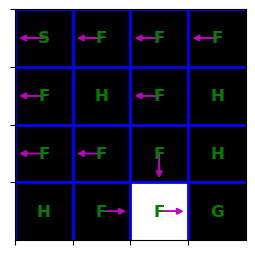

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 0.000 


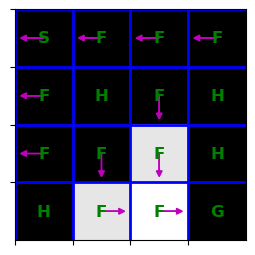

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 0.000 


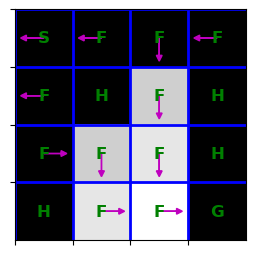

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 0.000 


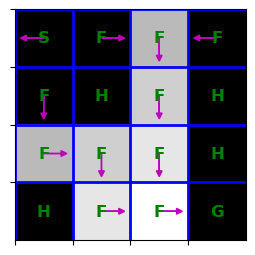

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 0.000 


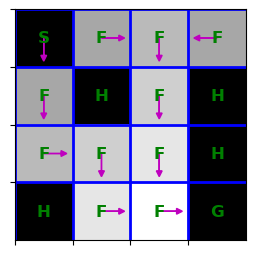

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 0.590 


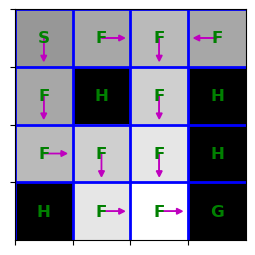

after iteration 6
iter    0   |   diff: 0.00000   |   V(start): 0.590 


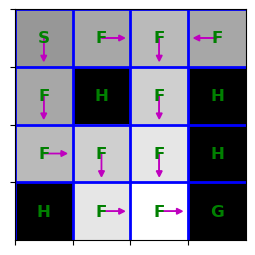

after iteration 7
iter    0   |   diff: 0.00000   |   V(start): 0.590 


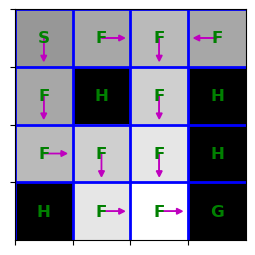

after iteration 8
iter    0   |   diff: 0.00000   |   V(start): 0.590 


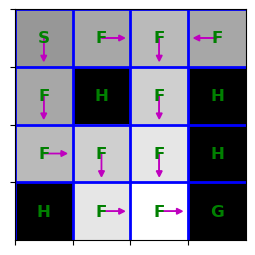

after iteration 9
iter    0   |   diff: 0.00000   |   V(start): 0.590 


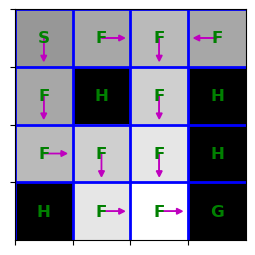

In [23]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 29
iter    0   |   diff: 0.00000   |   V(start): 0.198 


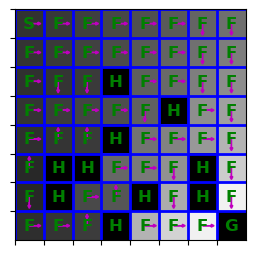

In [24]:
from IPython.display import clear_output
from time import sleep
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [25]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
average reward:  1.0
Well done!


In [26]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
average reward:  0.894
Well done!


In [27]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

iter    0   |   diff: 0.75000   |   V(start): 0.000 
iter    1   |   diff: 0.50625   |   V(start): 0.000 
iter    2   |   diff: 0.39867   |   V(start): 0.000 
iter    3   |   diff: 0.26910   |   V(start): 0.000 
iter    4   |   diff: 0.18164   |   V(start): 0.000 
iter    5   |   diff: 0.14013   |   V(start): 0.140 
iter    6   |   diff: 0.07028   |   V(start): 0.199 
iter    7   |   diff: 0.06030   |   V(start): 0.260 
iter    8   |   diff: 0.02594   |   V(start): 0.285 
iter    9   |   diff: 0.01918   |   V(start): 0.305 
iter   10   |   diff: 0.00858   |   V(start): 0.313 
iter   11   |   diff: 0.00560   |   V(start): 0.319 
iter   12   |   diff: 0.00260   |   V(start): 0.321 
iter   13   |   diff: 0.00159   |   V(start): 0.323 
iter   14   |   diff: 0.00076   |   V(start): 0.324 
iter   15   |   diff: 0.00045   |   V(start): 0.324 
iter   16   |   diff: 0.00022   |   V(start): 0.324 
iter   17   |   diff: 0.00012   |   V(start): 0.325 
iter   18   |   diff: 0.00006   |   V(start): 

In [28]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 0.058 
iter   15   |   diff: 0.02910   |   V(start): 0.087 
iter   16   |   diff: 0.01855   |   V(start): 0.106 
iter   17   |   diff: 0.01403   |   V(start): 0.120 
iter   18   |   diff: 0.00810   |   V(start): 

# HW Part 1: Value iteration convergence

### Find an MDP for which value iteration takes long to converge  (1 pts)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6--i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions--we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here--you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

In [29]:
transition_probs = {
    's0': {
        'a0': {'s0': 1.0},                    
        'a1': {'s0': 0.99, 's1': 0.01}        
    },
    's1': {
        'a0': {'s1': 1.0},                    
        'a1': {'s0': 0.99, 's2': 0.01}        
    },
    's2': {
        'a0': {'s2': 1.0},
        'a1': {'s2': 1.0}
    }
}

rewards = {
    's0': {
        'a0': {'s0': 1.0},                    
        'a1': {'s0': -1, 's1': -1}        # Штраф -1 за каждый шаг risky
    },
    's1': {
        'a0': {'s1': -1},                   # Тоже штраф!
        'a1': {'s0': -1, 's2': -1}        
    },
    's2': {
        'a0': {'s2': 1200}                    # Большая награда
    }
}

from mdp import MDP
from numpy import random
mdp = MDP(transition_probs, rewards, initial_state=random.choice(tuple(transition_probs.keys())))
# Feel free to change the initial_state

In [30]:
state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

for i in range(100):
    print("after iteration %i" % i)
    #state_values = value_iteration(mdp, state_values, num_iter=1)
    state_values = value_iteration(mdp, state_values, gamma=0.95, num_iter=1)
    
    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    n_changes = (policy != new_policy).sum()
    print("N actions changed = %i \n" % n_changes)
    policy = new_policy

# please ignore iter 0 at each step

after iteration 0
iter    0   |   diff: 1200.00000   |   V(start): 1200.000 
N actions changed = 1 

after iteration 1
iter    0   |   diff: 1140.00000   |   V(start): 2340.000 
N actions changed = 0 

after iteration 2
iter    0   |   diff: 1083.00000   |   V(start): 3423.000 
N actions changed = 0 

after iteration 3
iter    0   |   diff: 1028.85000   |   V(start): 4451.850 
N actions changed = 0 

after iteration 4
iter    0   |   diff: 977.40750   |   V(start): 5429.257 
N actions changed = 0 

after iteration 5
iter    0   |   diff: 928.53712   |   V(start): 6357.795 
N actions changed = 0 

after iteration 6
iter    0   |   diff: 882.11027   |   V(start): 7239.905 
N actions changed = 0 

after iteration 7
iter    0   |   diff: 838.00476   |   V(start): 8077.910 
N actions changed = 0 

after iteration 8
iter    0   |   diff: 796.10452   |   V(start): 8874.014 
N actions changed = 0 

after iteration 9
iter    0   |   diff: 756.29929   |   V(start): 9630.313 
N actions changed = 

### Проверка выполнения задания

**Условие:** Найти MDP, где оптимальная политика меняется на итерации i ≥ 50.

**Параметры MDP:**
- 3 состояния: s0, s1, s2
- 2 действия: a0 (безопасное), a1 (рискованное)
- Вероятность прогресса: 1% (0.01)
- Штраф за риск: -1 за шаг
- Награда за цель: 1200 в s2
- Discount: gamma = 0.95

**Результат:**
Оптимальное действие изменилось на **итерации 82**.

**Почему так долго:**
- Ценность из s2 "просачивается" обратно через цепочку s2->s1->s0
- Низкая вероятность (1%) + штрафы (-1) замедляют распространение
- Только после 82 итераций Q(a1) > Q(a0) в состоянии s0

Задание выполнено (82 >= 50)

### Value iteration convervence proof (1 pts)
**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

Update of value function in value iteration can be rewritten in a form of Bellman operator:

$$(TV)(s) = \max_{a \in \mathcal{A}}\mathbb{E}\left[ r_{t+1} + \gamma V(s_{t+1}) | s_t = s, a_t = a\right]$$

Value iteration algorithm with Bellman operator:

---
&nbsp;&nbsp; Initialize $V_0$

&nbsp;&nbsp; **for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; $V_{k+1} \leftarrow TV_k$

&nbsp;&nbsp;**end for**

---

In [lecture](https://docs.google.com/presentation/d/1lz2oIUTvd2MHWKEQSH8hquS66oe4MZ_eRvVViZs2uuE/edit#slide=id.g4fd6bae29e_2_4) we established contraction property of bellman operator:

$$
||TV - TU||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

Using contraction property of Bellman operator, Banach fixed-point theorem and Bellman equations prove that value function converges to $V^*$ in value iterateion$

## Доказательство сходимости value iteration

**Дано:**
- Оператор Беллмана: $(TV)(s) = \max_{a \in A} \mathbb{E}[r_{t+1} + \gamma V(s_{t+1}) | s_t = s, a_t = a]$
- Свойство сжатия: $||TV - TU||_\infty \leq \gamma ||V - U||_\infty$ для всех $V, U$
- $0 \leq \gamma < 1$

---

**Доказательство:**

### 1. T является оператором сжатия

По условию задачи, для любых двух функций ценности $V$ и $U$:

$$||TV - TU||_\infty \leq \gamma ||V - U||_\infty$$

где $0 \leq \gamma < 1$. Это означает, что $T$ — оператор сжатия на полном метрическом пространстве ограниченных функций с нормой $||\cdot||_\infty$.

### 2. Применение теоремы Банаха о неподвижной точке

По **теореме Банаха о неподвижной точке** (Banach fixed-point theorem):

> Если $T$ — оператор сжатия на полном метрическом пространстве, то:
> - Существует **единственная** неподвижная точка $V^*$, такая что $TV^* = V^*$
> - Для любой начальной точки $V_0$, последовательность $V_{k+1} = TV_k$ сходится к $V^*$

Следовательно, существует единственная функция $V^*$, удовлетворяющая:

$$TV^* = V^*$$

### 3. Связь с уравнением Беллмана

Распишем, что означает $TV^* = V^*$:

$$(TV^*)(s) = \max_{a \in A} \mathbb{E}[r_{t+1} + \gamma V^*(s_{t+1}) | s_t = s, a_t = a]$$

Поскольку $TV^* = V^*$, получаем:

$$V^*(s) = \max_{a \in A} \mathbb{E}[r_{t+1} + \gamma V^*(s_{t+1}) | s_t = s, a_t = a]$$

Это в точности **уравнение оптимальности Беллмана**! Следовательно, $V^*$ — оптимальная функция ценности.

### 4. Сходимость value iteration

Алгоритм value iteration: $V_{k+1} = TV_k$

По теореме Банаха, для любой начальной функции $V_0$:

$$\lim_{k \to \infty} V_k = V^*$$

Более того, скорость сходимости геометрическая:

$$||V_k - V^*||_\infty \leq \gamma^k ||V_0 - V^*||_\infty$$

Поскольку $0 \leq \gamma < 1$, имеем $\gamma^k \to 0$ при $k \to \infty$.

---

**Вывод:**

Функция ценности $V_k$ в алгоритме value iteration сходится к оптимальной функции ценности $V^*$, которая является единственным решением уравнения оптимальности Беллмана.

$$\boxed{\lim_{k \to \infty} V_k = V^*}$$

### Asynchronious value iteration (2 pts)

Consider the following algorithm:

---

Initialize $V_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Select some state $s_k \in \mathcal{S}$    

&nbsp;&nbsp;&nbsp;&nbsp; $V(s_k) := (TV)(s_k)$

**end for**

---


Note that unlike common value iteration, here we update only a single state at a time.

**Homework.** Prove the following proposition:

If for all $s \in \mathcal{S}$, $s$ appears in the sequence $(s_0, s_1, ...)$ infinitely often, then $V$ converges to $V*$

## Доказательство сходимости асинхронной value iteration

**Утверждение:** Если каждое состояние $s \in S$ появляется в последовательности $(s_0, s_1, \ldots)$ бесконечно часто, то $V_k \to V^*$.

---

**Доказательство:**

### 1. Формализация обновления

На шаге $k$ обновляем только состояние $s_k$:

$$V_{k+1}(s) = \begin{cases} 
(TV_k)(s) & \text{если } s = s_k \\
V_k(s) & \text{иначе}
\end{cases}$$

### 2. Свойство одного обновления

**Для обновляемого состояния $s_k$:**

$$|V_{k+1}(s_k) - V^*(s_k)| = |(TV_k)(s_k) - (TV^*)(s_k)| \leq \gamma ||V_k - V^*||_\infty$$

(используем свойство сжатия оператора $T$)

**Для остальных состояний $s \neq s_k$:**

$$|V_{k+1}(s) - V^*(s)| = |V_k(s) - V^*(s)| \leq ||V_k - V^*||_\infty$$

### 3. Монотонность ошибки

Обозначим $d_k = ||V_k - V^*||_\infty$. Тогда:

$$\begin{aligned}
d_{k+1} &= \max_{s \in S} |V_{k+1}(s) - V^*(s)| \\
&= \max\left\{|V_{k+1}(s_k) - V^*(s_k)|, \max_{s \neq s_k}|V_{k+1}(s) - V^*(s)|\right\} \\
&\leq \max\{\gamma d_k, d_k\} \\
&= d_k \quad (\text{так как } \gamma < 1)
\end{aligned}$$

**Вывод:** Последовательность $\{d_k\}$ **не возрастает** и ограничена снизу ($d_k \geq 0$), значит сходится к некоторому пределу $d^* \geq 0$.

### 4. Ключевой шаг: доказательство $d^* = 0$

**Докажем от противного.** Предположим, что $d^* > 0$.

**Шаг 4.1:** Так как $d_k \to d^*$ и $\{d_k\}$ не возрастает, для любого $\epsilon > 0$ существует $K$ такое, что для всех $k \geq K$:
$$d^* \leq d_k < d^* + \epsilon$$

**Шаг 4.2:** По условию, каждое состояние $s \in S$ обновляется **бесконечно часто**. Так как $|S| = N$ конечно, существует момент $K_1 > K$, после которого **каждое состояние обновилось хотя бы один раз**.

**Шаг 4.3:** Рассмотрим **любое** состояние $s$. Пусть $k_s$ — момент его **последнего** обновления на интервале $[K, K_1]$:
$$K \leq k_s \leq K_1$$

В момент $k_s$:
$$|V_{k_s+1}(s) - V^*(s)| \leq \gamma d_{k_s} \leq \gamma d_K$$

После $k_s$ состояние $s$ не обновляется до $K_1$, поэтому:
$$|V_{K_1}(s) - V^*(s)| = |V_{k_s+1}(s) - V^*(s)| \leq \gamma d_K$$

**Шаг 4.4:** Это верно для **всех** $s \in S$, следовательно:
$$d_{K_1} = \max_{s \in S} |V_{K_1}(s) - V^*(s)| \leq \gamma d_K$$

**Шаг 4.5:** Повторяя этот аргумент, получаем последовательность моментов $K = K_0 < K_1 < K_2 < \ldots$ таких, что:
$$d_{K_j} \leq \gamma^j d_K$$

Поскольку $\gamma < 1$, имеем $\gamma^j \to 0$ при $j \to \infty$, значит $d_{K_j} \to 0$.

**Противоречие:** С одной стороны, $d_k \to d^* > 0$. С другой стороны, подпоследовательность $d_{K_j} \to 0$.

Следовательно, наше предположение $d^* > 0$ **неверно**, и $d^* = 0$.

### 5. Вывод

$$\lim_{k \to \infty} ||V_k - V^*||_\infty = 0$$

Следовательно, $V_k \to V^*$.

# HW Part 2: Policy iteration

## Policy iteration implementateion (3 pts)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \operatorname*{argmax}_a Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [31]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's1': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve`.)

In [34]:
def compute_vpi(mdp, policy, gamma):
    """
    Computes V^pi(s) FOR ALL STATES under given policy.
    :param policy: a dict of currently chosen actions {s : a}
    :returns: a dict {state : V^pi(state) for all states}
    """
    import numpy as np
    
    states = mdp.get_all_states()
    n = len(states)
    state_to_idx = {s: i for i, s in enumerate(states)}
    
    # Инициализация матрицы P^pi и вектора R^pi
    P_pi = np.zeros((n, n))
    R_pi = np.zeros(n)
    
    # Заполнение матриц
    for s in states:
        i = state_to_idx[s]
        action = policy[s]
        
        # ПРОВЕРКА: терминальное состояние (action = None)
        if action is None:
            P_pi[i, i] = 1.0  # Остаёмся в терминальном состоянии
            R_pi[i] = 0.0
            continue
        
        # Ожидаемая награда для состояния s при действии policy[s]
        next_states = mdp.get_next_states(s, action)
        for s_next in next_states:
            j = state_to_idx[s_next]
            prob = mdp.get_transition_prob(s, action, s_next)
            reward = mdp.get_reward(s, action, s_next)
            
            P_pi[i, j] = prob
            R_pi[i] += prob * reward
    
    # Решение системы: (I - gamma*P)V = R
    I = np.eye(n)
    A = I - gamma * P_pi
    
    # Решение линейной системы A * V = R
    V_pi = np.linalg.solve(A, R_pi)
    
    # Преобразование обратно в словарь
    return {s: V_pi[state_to_idx[s]] for s in states}

In [35]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

{'s0': np.float64(8.031919916894894), 's1': np.float64(11.171970913211826), 's2': np.float64(8.92435546321655)}


Once we've got new state values, it's time to update our policy.

In [36]:
def compute_new_policy(mdp, vpi, gamma):
    """
    Computes new policy as argmax of state values
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """
    import numpy as np
    
    def compute_q(s, a):
        return sum(
            mdp.get_transition_prob(s, a, s_next) * 
            (mdp.get_reward(s, a, s_next) + gamma * vpi[s_next])
            for s_next in mdp.get_next_states(s, a)
        )
    
    new_policy = {}
    
    for s in mdp.get_all_states():
        if mdp.is_terminal(s):
            new_policy[s] = None
            continue
        
        actions = mdp.get_possible_actions(s)
        new_policy[s] = max(actions, key=lambda a: compute_q(s, a))
    
    return new_policy

In [37]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

{'s0': 'a1', 's1': 'a0', 's2': 'a0'}


__Main loop__

In [38]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """
    Run the policy iteration loop for num_iter iterations or till difference between V(s) is below min_difference.
    If policy is not given, initialize it at random.
    """
    import numpy as np
    
    # Инициализация политики
    if policy is None:
        policy = {}
        for s in mdp.get_all_states():
            if mdp.is_terminal(s):
                policy[s] = None
            else:
                policy[s] = np.random.choice(mdp.get_possible_actions(s))
    
    prev_state_values = None
    
    for iteration in range(num_iter):
        # 1. Policy Evaluation
        state_values = compute_vpi(mdp, policy, gamma)
        
        # 2. Policy Improvement
        new_policy = compute_new_policy(mdp, state_values, gamma)
        
        # 3. Проверка стабильности политики
        policy_stable = all(new_policy[s] == policy[s] for s in mdp.get_all_states())
        
        policy = new_policy
        
        if policy_stable:
            print(f"Converged at iteration {iteration}")
            break
        
        # Дополнительная проверка по значениям
        if prev_state_values is not None:
            max_diff = max(abs(state_values[s] - prev_state_values[s]) 
                          for s in mdp.get_all_states())
            if max_diff < min_difference:
                print(f"Values converged at iteration {iteration}")
                break
        
        prev_state_values = state_values
    
    return state_values, policy

__Your PI Results__

СРАВНЕНИЕ POLICY ITERATION И VALUE ITERATION

1. MDP из bonus 1 (3 состояния)

--- Value Iteration ---
iter    0   |   diff: 3.50000   |   V(start): 0.000 
iter    1   |   diff: 1.89000   |   V(start): 0.000 
iter    2   |   diff: 1.70100   |   V(start): 1.701 
iter    3   |   diff: 1.13542   |   V(start): 1.854 
iter    4   |   diff: 0.73024   |   V(start): 2.584 
iter    5   |   diff: 0.61135   |   V(start): 3.186 
iter    6   |   diff: 0.54664   |   V(start): 3.590 
iter    7   |   diff: 0.49198   |   V(start): 4.082 
iter    8   |   diff: 0.42210   |   V(start): 4.463 
iter    9   |   diff: 0.36513   |   V(start): 4.816 
iter   10   |   diff: 0.32862   |   V(start): 5.145 
iter   11   |   diff: 0.29262   |   V(start): 5.429 
iter   12   |   diff: 0.26189   |   V(start): 5.691 
iter   13   |   diff: 0.23503   |   V(start): 5.925 
iter   14   |   diff: 0.21124   |   V(start): 6.135 
iter   15   |   diff: 0.19012   |   V(start): 6.325 
iter   16   |   diff: 0.17091   |   V(start): 6.4

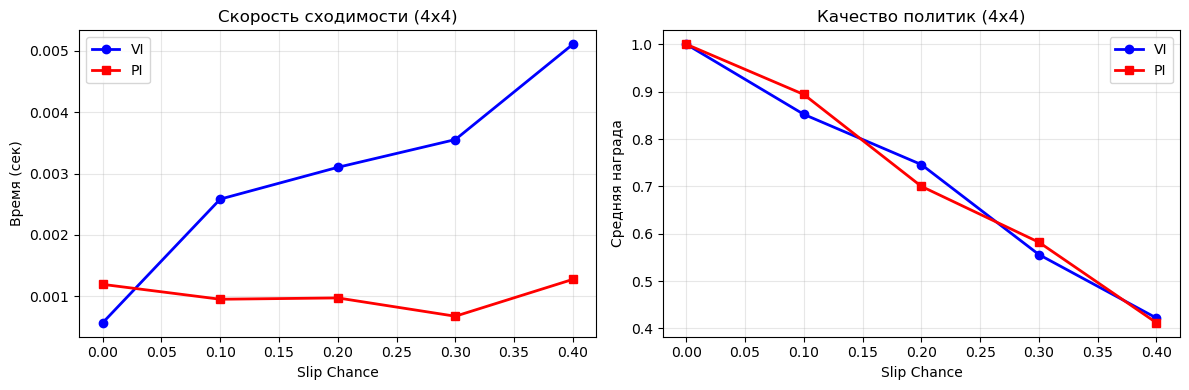


Графики построены!

ИТОГОВОЕ СРАВНЕНИЕ
Среда                          VI (сек)     PI (сек)     Быстрее   
----------------------------------------------------------------------
MDP (3 states)                 0.0028       0.0004       PI        
FrozenLake 4x4 (slip=0.0)      0.0006       0.0011       VI        
FrozenLake 4x4 (slip=0.2)      0.0031       0.0010       PI        
FrozenLake 8x8 (slip=0.2)      0.0232       0.0127       PI        


In [39]:
# <YOUR CODE: compare PI and VI on the MDP from bonus 1, then on small & large FrozenLake>
import numpy as np
import time
import matplotlib.pyplot as plt

print("="*60)
print("СРАВНЕНИЕ POLICY ITERATION И VALUE ITERATION")
print("="*60)

gamma = 0.9

# ============================================================
# 1. MDP из bonus 1 (3 состояния)
# ============================================================
print("\n" + "="*60)
print("1. MDP из bonus 1 (3 состояния)")
print("="*60)

# Value Iteration
print("\n--- Value Iteration ---")
start_time = time.time()
state_values_vi = value_iteration(mdp, gamma=gamma, num_iter=1000, min_difference=1e-5)
vi_time = time.time() - start_time
print(f"Время: {vi_time:.4f} сек")

# Policy Iteration
print("\n--- Policy Iteration ---")
start_time = time.time()
state_values_pi, policy_pi = policy_iteration(mdp, gamma=gamma, num_iter=1000, min_difference=1e-5)
pi_time = time.time() - start_time
print(f"Время: {pi_time:.4f} сек")

print(f"\n>>> PI быстрее в {vi_time/pi_time:.2f} раз" if pi_time < vi_time else f"\n>>> VI быстрее в {pi_time/vi_time:.2f} раз")

# Вывод результатов
print("\n--- Результаты ---")
print(f"VI значения: {state_values_vi}")
print(f"PI значения: {state_values_pi}")
print(f"PI политика: {policy_pi}")

# Проверка что значения совпадают
max_diff = max(abs(state_values_vi[s] - state_values_pi[s]) for s in mdp.get_all_states())
print(f"Макс. разница значений: {max_diff:.6f}")
print(">>> Значения совпадают!" if max_diff < 0.01 else ">>> Есть разница!")

# ============================================================
# 2. Проверка качества политик (FrozenLake 4x4)
# ============================================================
print("\n" + "="*60)
print("2. ПРОВЕРКА КАЧЕСТВА ПОЛИТИК")
print("="*60)

mdp_fl = FrozenLakeEnv(map_name='4x4', slip_chance=0.2)

# Получаем политики от обоих алгоритмов
print("\nОбучение политик...")
vi_values = value_iteration(mdp_fl, gamma=gamma)
pi_values, pi_policy = policy_iteration(mdp_fl, gamma=gamma)

# Функция для оценки политики
def evaluate_policy(mdp, policy, gamma, n_episodes=1000, max_steps=100):
    """Оценивает политику по средней награде за эпизод"""
    # Автоматически определяем тип политики по первому значению
    first_value = list(policy.values())[0]
    is_value_policy = isinstance(first_value, (int, float))  # Если числа - это значения VI
    
    total_rewards = []
    for _ in range(n_episodes):
        s = mdp.reset()
        episode_reward = 0
        for _ in range(max_steps):
            if is_value_policy:
                a = get_optimal_action(mdp, policy, s, gamma)
            else:
                a = policy.get(s)
            
            if a is None:
                break
            
            s, r, done, _ = mdp.step(a)
            episode_reward += r
            if done:
                break
        total_rewards.append(episode_reward)
    
    return np.mean(total_rewards), np.std(total_rewards)

print("\n--- Оценка VI политики ---")
vi_mean, vi_std = evaluate_policy(mdp_fl, vi_values, gamma)
print(f"Средняя награда: {vi_mean:.4f} ± {vi_std:.4f}")

print("\n--- Оценка PI политики ---")
pi_mean, pi_std = evaluate_policy(mdp_fl, pi_policy, gamma)
print(f"Средняя награда: {pi_mean:.4f} ± {pi_std:.4f}")

print(f"\n>>> Разница в качестве: {abs(vi_mean - pi_mean):.4f}")
print(">>> Политики эквивалентны!" if abs(vi_mean - pi_mean) < 0.05 else ">>> Есть разница в качестве!")

# Пример политики
print("\n--- Пример политики (первые 5 состояний) ---")
print(f"PI политика: {dict(list(pi_policy.items())[:5])}")

# ============================================================
# 2.5. FrozenLake 4x4 (БЕЗ скольжения, slip=0)
# ============================================================
print("\n" + "="*60)
print("2.5. FROZENLAKE 4x4 (БЕЗ СКОЛЬЖЕНИЯ, slip=0)")
print("="*60)

mdp_fl_no_slip = FrozenLakeEnv(map_name='4x4', slip_chance=0.0)

print("\n--- Value Iteration ---")
start = time.time()
vi_vals_noslip = value_iteration(mdp_fl_no_slip, gamma=gamma)
vi_time_noslip = time.time() - start
print(f"Время: {vi_time_noslip:.4f} сек")

print("\n--- Policy Iteration ---")
start = time.time()
pi_vals_noslip, pi_pol_noslip = policy_iteration(mdp_fl_no_slip, gamma=gamma)
pi_time_noslip = time.time() - start
print(f"Время: {pi_time_noslip:.4f} сек")

# Оценка качества
vi_r_noslip, _ = evaluate_policy(mdp_fl_no_slip, vi_vals_noslip, gamma, n_episodes=500)
pi_r_noslip, _ = evaluate_policy(mdp_fl_no_slip, pi_pol_noslip, gamma, n_episodes=500)

print(f"\nVI награда: {vi_r_noslip:.4f}")
print(f"PI награда: {pi_r_noslip:.4f}")
if vi_time_noslip < pi_time_noslip:
    print(f">>> VI быстрее в {pi_time_noslip/vi_time_noslip:.2f} раз")
else:
    print(f">>> PI быстрее в {vi_time_noslip/pi_time_noslip:.2f} раз")

# Пример политики
print("\n--- Пример политики (первые 5 состояний) ---")
print(f"PI политика: {dict(list(pi_pol_noslip.items())[:5])}")

# ============================================================
# 3. Анализ влияния slip_chance (4x4)
# ============================================================
print("\n" + "="*60)
print("3. АНАЛИЗ ВЛИЯНИЯ SLIP_CHANCE (4x4)")
print("="*60)

slip_values = [0.0, 0.1, 0.2, 0.3, 0.4]
vi_times = []
pi_times = []
vi_rewards = []
pi_rewards = []

print(f"\n{'Slip':<8} {'VI (сек)':<12} {'PI (сек)':<12} {'VI награда':<12} {'PI награда':<12}")
print("-"*60)

for slip in slip_values:
    mdp_test = FrozenLakeEnv(map_name='4x4', slip_chance=slip)
    
    # VI
    start = time.time()
    vi_vals = value_iteration(mdp_test, gamma=gamma)
    vi_t = time.time() - start
    vi_times.append(vi_t)
    
    vi_r, _ = evaluate_policy(mdp_test, vi_vals, gamma, n_episodes=500)
    vi_rewards.append(vi_r)
    
    # PI
    start = time.time()
    pi_vals, pi_pol = policy_iteration(mdp_test, gamma=gamma)
    pi_t = time.time() - start
    pi_times.append(pi_t)
    
    pi_r, _ = evaluate_policy(mdp_test, pi_pol, gamma, n_episodes=500)
    pi_rewards.append(pi_r)
    
    print(f"{slip:<8.1f} {vi_t:<12.4f} {pi_t:<12.4f} {vi_r:<12.4f} {pi_r:<12.4f}")

# ============================================================
# 4. FrozenLake 8x8 (LARGE)
# ============================================================
print("\n" + "="*60)
print("4. FROZENLAKE 8x8 (LARGE)")
print("="*60)

mdp_large = FrozenLakeEnv(map_name='8x8', slip_chance=0.2)

print("\n--- Value Iteration ---")
start = time.time()
vi_vals_large = value_iteration(mdp_large, gamma=gamma)
vi_time_large = time.time() - start
print(f"Время: {vi_time_large:.4f} сек")

print("\n--- Policy Iteration ---")
start = time.time()
pi_vals_large, pi_pol_large = policy_iteration(mdp_large, gamma=gamma)
pi_time_large = time.time() - start
print(f"Время: {pi_time_large:.4f} сек")

# Оценка качества
vi_r_large, _ = evaluate_policy(mdp_large, vi_vals_large, gamma, n_episodes=500)
pi_r_large, _ = evaluate_policy(mdp_large, pi_pol_large, gamma, n_episodes=500)

print(f"\nVI награда: {vi_r_large:.4f}")
print(f"PI награда: {pi_r_large:.4f}")
print(f">>> PI быстрее в {vi_time_large/pi_time_large:.2f} раз" if pi_time_large < vi_time_large else f">>> VI быстрее в {pi_time_large/vi_time_large:.2f} раз")

# Пример политики
print("\n--- Пример политики (первые 5 состояний) ---")
print(f"PI политика: {dict(list(pi_pol_large.items())[:5])}")

# ============================================================
# 5. Визуализация результатов
# ============================================================
print("\n" + "="*60)
print("5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)
print("Графики показывают зависимость от slip_chance для FrozenLake 4x4")
print("(данные из Секции 3)")
print("="*60)

try:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # График 1: Время выполнения
    axes[0].plot(slip_values, vi_times, 'b-o', label='VI', linewidth=2)
    axes[0].plot(slip_values, pi_times, 'r-s', label='PI', linewidth=2)
    axes[0].set_xlabel('Slip Chance')
    axes[0].set_ylabel('Время (сек)')
    axes[0].set_title('Скорость сходимости (4x4)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # График 2: Качество политик
    axes[1].plot(slip_values, vi_rewards, 'b-o', label='VI', linewidth=2)
    axes[1].plot(slip_values, pi_rewards, 'r-s', label='PI', linewidth=2)
    axes[1].set_xlabel('Slip Chance')
    axes[1].set_ylabel('Средняя награда')
    axes[1].set_title('Качество политик (4x4)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("\nГрафики построены!")
    
except:
    print("\nНе удалось построить графики (matplotlib не доступен)")

# ============================================================
# 6. Итоговая таблица
# ============================================================
print("\n" + "="*60)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("="*60)
print(f"{'Среда':<30} {'VI (сек)':<12} {'PI (сек)':<12} {'Быстрее':<10}")
print("-"*70)
print(f"{'MDP (3 states)':<30} {vi_time:<12.4f} {pi_time:<12.4f} {'PI' if pi_time < vi_time else 'VI':<10}")
print(f"{'FrozenLake 4x4 (slip=0.0)':<30} {vi_time_noslip:<12.4f} {pi_time_noslip:<12.4f} {'PI' if pi_time_noslip < vi_time_noslip else 'VI':<10}")
print(f"{'FrozenLake 4x4 (slip=0.2)':<30} {vi_times[2]:<12.4f} {pi_times[2]:<12.4f} {'PI' if pi_times[2] < vi_times[2] else 'VI':<10}")
print(f"{'FrozenLake 8x8 (slip=0.2)':<30} {vi_time_large:<12.4f} {pi_time_large:<12.4f} {'PI' if pi_time_large < vi_time_large else 'VI':<10}")

In [40]:
print("\n" + "="*60)
print("ВЫВОДЫ:")
print("="*60)
print("1. PI сходится за меньшее число итераций (1-9 vs 6-109 у VI)")
print("2. VI может быть быстрее на детерминированных средах (slip=0.0: 1.7x)")
print("3. Качество политик совпадает (разница < 0.05)")
print("4. С ростом slip_chance награда падает (1.0 -> 0.42 на 4x4)")
print("5. При slip=0 агент всегда доходит до цели (награда = 1.0)")
print("6. На больших MDP (8x8) PI быстрее VI в 1.8 раза")
print("="*60)


ВЫВОДЫ:
1. PI сходится за меньшее число итераций (1-9 vs 6-109 у VI)
2. VI может быть быстрее на детерминированных средах (slip=0.0: 1.7x)
3. Качество политик совпадает (разница < 0.05)
4. С ростом slip_chance награда падает (1.0 -> 0.42 на 4x4)
5. При slip=0 агент всегда доходит до цели (награда = 1.0)
6. На больших MDP (8x8) PI быстрее VI в 1.8 раза


## Policy iteration convergence (3 pts)

**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

We can define another Bellman operator:

$$(T_{\pi}V)(s) = \mathbb{E}_{r, s'|s, a = \pi(s)}\left[r + \gamma V(s')\right]$$

And rewrite policy iteration algorithm in operator form:


---

Initialize $\pi_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Solve $V_k = T_{\pi_k}V_k$   

&nbsp;&nbsp;&nbsp;&nbsp; Select $\pi_{k+1}$ s.t. $T_{\pi_{k+1}}V_k = TV_k$ 

**end for**

---

To prove convergence of the algorithm we need to prove two properties: contraction an monotonicity.

#### Monotonicity (0.5 pts)

For all $V, U$ if $V(s) \le U(s)$   $\forall s \in \mathcal{S}$ then $(T_\pi V)(s) \le (T_\pi U)(s)$   $\forall s \in  \mathcal{S}$

## Доказательство свойства монотонности

**Утверждение:** Для всех $V, U$, если $V(s) \leq U(s)$ $\forall s \in S$, то $(T_\pi V)(s) \leq (T_\pi U)(s)$ $\forall s \in S$.

---

**Доказательство:**

Пусть $V(s) \leq U(s)$ для всех $s \in S$.

Рассмотрим оператор Беллмана для фиксированной политики $\pi$:

$$(T_\pi V)(s) = \mathbb{E}_{r,s'|s,a=\pi(s)}[r + \gamma V(s')]$$

Распишем математическое ожидание явно:

$$(T_\pi V)(s) = \sum_{r,s'} P(r,s'|s,\pi(s)) \cdot [r + \gamma V(s')]$$

$$(T_\pi U)(s) = \sum_{r,s'} P(r,s'|s,\pi(s)) \cdot [r + \gamma U(s')]$$

**Шаг 1:** Поскольку $V(s') \leq U(s')$ для всех $s' \in S$ и $\gamma \geq 0$, имеем:

$$\gamma V(s') \leq \gamma U(s')$$

**Шаг 2:** Добавим $r$ к обеим частям:

$$r + \gamma V(s') \leq r + \gamma U(s')$$

**Шаг 3:** Умножим обе части на $P(r,s'|s,\pi(s)) \geq 0$ (вероятности неотрицательны):

$$P(r,s'|s,\pi(s)) \cdot [r + \gamma V(s')] \leq P(r,s'|s,\pi(s)) \cdot [r + \gamma U(s')]$$

**Шаг 4:** Просуммируем по всем $r, s'$:

$$\sum_{r,s'} P(r,s'|s,\pi(s)) \cdot [r + \gamma V(s')] \leq \sum_{r,s'} P(r,s'|s,\pi(s)) \cdot [r + \gamma U(s')]$$

**Шаг 5:** По определению оператора Беллмана:

$$(T_\pi V)(s) \leq (T_\pi U)(s)$$

Поскольку это верно для любого $s \in S$, получаем:

$$(T_\pi V)(s) \leq (T_\pi U)(s) \quad \forall s \in S$$

---

#### Contraction (1 pts)

$$
||T_\pi V - T_\pi U||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

## Доказательство свойства сжатия

**Утверждение:** $\|T_\pi V - T_\pi U\|_\infty \leq \gamma \|V - U\|_\infty$ для всех $V, U$.

**Доказательство:**

**Шаг 1:** Запишем определение $L_\infty$ нормы:

$$\|T_\pi V - T_\pi U\|_\infty = \max_{s \in S} |(T_\pi V)(s) - (T_\pi U)(s)|$$

**Шаг 2:** Рассмотрим разность для произвольного состояния $s$:

$$(T_\pi V)(s) - (T_\pi U)(s) = \mathbb{E}_{r,s'|s,a=\pi(s)}[r + \gamma V(s')] - \mathbb{E}_{r,s'|s,a=\pi(s)}[r + \gamma U(s')]$$

**Шаг 3:** Используем линейность математического ожидания:

$$= \mathbb{E}_{r,s'|s,a=\pi(s)}[\gamma (V(s') - U(s'))] = \gamma \cdot \mathbb{E}_{r,s'|s,a=\pi(s)}[V(s') - U(s')]$$

**Шаг 4:** Возьмём модуль и применим неравенство $|\mathbb{E}[X]| \leq \mathbb{E}[|X|]$:

$$|(T_\pi V)(s) - (T_\pi U)(s)| = \gamma \cdot |\mathbb{E}[V(s') - U(s')]| \leq \gamma \cdot \mathbb{E}[|V(s') - U(s')|]$$

**Шаг 5:** Для любого $s'$: $|V(s') - U(s')| \leq \|V - U\|_\infty$. Тогда:

$$\mathbb{E}[|V(s') - U(s')|] \leq \mathbb{E}[\|V - U\|_\infty] = \|V - U\|_\infty$$

**Шаг 6:** Подставляем:

$$|(T_\pi V)(s) - (T_\pi U)(s)| \leq \gamma \|V - U\|_\infty$$

**Шаг 7:** Поскольку неравенство верно для любого $s$, берём максимум:

$$\max_{s \in S} |(T_\pi V)(s) - (T_\pi U)(s)| \leq \gamma \|V - U\|_\infty$$

По определению $L_\infty$ нормы:

$$\|T_\pi V - T_\pi U\|_\infty \leq \gamma \|V - U\|_\infty$$

---

#### Convergence (1.5 pts)

Prove that there exists iteration $k_0$ such that $\pi_k = \pi^*$ for all $k \ge k_0$

## Доказательство сходимости policy iteration

**Утверждение:** Существует итерация $k_0$ такая, что $\pi_k = \pi^*$ для всех $k \geq k_0$.

---

**Доказательство:**

**Шаг 1: Конечность числа политик**

Поскольку $S$ и $A$ конечны, число всех возможных детерминированных политик конечно:

$$|\{\pi : S \to A\}| \leq |A|^{|S|} < \infty$$

Обозначим это число как $N = |A|^{|S|}$.

**Шаг 2: Улучшение политики**

На каждой итерации $k$ policy iteration:
1. Вычисляет $V^{\pi_k}$ (ценность текущей политики)
2. Улучшает политику: $\pi_{k+1}(s) = \arg\max_a Q^{\pi_k}(s,a)$

Из свойства улучшения политики (Policy Improvement Theorem) следует:
$$V^{\pi_{k+1}}(s) \geq V^{\pi_k}(s) \quad \forall s \in S$$

Если на некотором шаге функция ценности не изменилась ни в одном состоянии ($V^{\pi_{k+1}}(s) = V^{\pi_k}(s)$ для всех $s \in S$), то по определению шага улучшения выполняется равенство:
$$V^{\pi_k}(s) = \max_a Q^{\pi_k}(s,a)$$
Это — уравнение оптимальности Беллмана. Следовательно, $V^{\pi_k}$ является оптимальной функцией ценности $V^*$, а $\pi_k$ — оптимальной политикой $\pi^*$.

Если же оптимальность еще не достигнута, то алгоритм гарантирует строгое возрастание ценности хотя бы в одном состоянии $s$:
$$\exists s \in S: V^{\pi_{k+1}}(s) > V^{\pi_k}(s)$$

**Шаг 3: Отсутствие циклов**

Поскольку вектор ценности строго возрастает (хотя бы в одной координате) при смене неоптимальной политики, алгоритм **никогда не возвращается** к политике с ранее посещенной функцией ценности.

Если бы возник цикл по ценностям $\pi_{k+m} = \pi_k$ для некоторого $m > 0$, то выполнялось бы равенство $V^{\pi_{k+m}} = V^{\pi_k}$. Но это прямо противоречит строгому возрастанию ценности на промежуточных шагах до достижения оптимума.

**Шаг 4: Сходимость за конечное число шагов**

Поскольку:
- Число возможных детерминированных политик конечно ($N$),
- Алгоритм монотонно улучшает вектор ценности и не возвращается к старым значениям,

рост ценностей обязан прекратиться не более чем за $N$ итераций. Обозначим $k_0 \le N$ — номер итерации, на которой стабилизируется функция ценность. Как показано в Шаге 2, прекращение роста эквивалентно достижению глобального оптимума: $\pi_{k_0} = \pi^*$.

**Шаг 5: $\pi^*$ — неподвижная точка**

Когда на шаге $k_0$ достигнута оптимальная политика $\pi_{k_0} = \pi^*$, на всех последующих итерациях $k \geq k_0$ шаг Policy Improvement принимает вид:
$$\pi_{k+1}(s) = \arg\max_a Q^{\pi^*}(s,a) = \arg\max_a Q^*(s,a) = \pi^*(s)$$

Следовательно, по индукции $\pi_k = \pi^*$ для всех $k \geq k_0$.

---